# **Task 1**


In this cell, we construct a dense kernel matrix based on the interaction 1/∣xi​−xj​∣.
The matrix is recursively split into smaller blocks in a hierarchical manner.
At each level of splitting, the off-diagonal blocks (top-right and bottom-left) are extracted.
For these blocks, both the exact rank and numerical rank are computed using SVD.
This allows us to observe how the numerical rank behaves as the block size decreases.
The recursion stops once the block size reaches a predefined minimum, where blocks are treated as dense.

In [ ]:
import numpy as np
def build_kernel_matrix(x):
    N = len(x)
    A = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            if i == j:
                A[i, j] = 100 * N
            else:
                A[i, j] = 1.0 / abs(x[i] - x[j])
    return A / N

def numerical_rank(A, eps=1e-4):
    _, S, _ = np.linalg.svd(A, full_matrices=False)
    return np.sum(S > eps * S[0])
def exact_rank(A):
    return np.linalg.matrix_rank(A)

def recursive_split(A, level=0, eps=1e-4, min_size=32):
    n = A.shape[0]
    indent = "  " * level

    # Stop condition
    if n <= min_size:
        print(f"{indent}Level {level}: block size {n} → STOP (stored dense)")
        return

    mid = n // 2


    A_tr = A[:mid, mid:]   # top-right
    A_bl = A[mid:, :mid]   # bottom-left

    # Numerical ranks
    num_rank_tr = numerical_rank(A_tr, eps)
    num_rank_bl = numerical_rank(A_bl, eps)

    # Exact (algebraic) ranks
    exact_rank_tr = exact_rank(A_tr)
    exact_rank_bl = exact_rank(A_bl)

    print(f"{indent}Level {level}: block size {n}")
    print(f"{indent}  Top-right  : exact rank = {exact_rank_tr}, numerical rank = {num_rank_tr}")
    print(f"{indent}  Bottom-left: exact rank = {exact_rank_bl}, numerical rank = {num_rank_bl}")

    # Recursively split diagonal blocks
    A_tl = A[:mid, :mid]
    A_br = A[mid:, mid:]

    recursive_split(A_tl, level + 1, eps, min_size)
    recursive_split(A_br, level + 1, eps, min_size)

# Problem size (keep moderate for SVD)
N = 256
x = np.linspace(0, 1, N)

A = build_kernel_matrix(x)

# Start recursive hierarchical splitting
recursive_split(A, eps=1e-4, min_size=32)


Level 0: block size 256
  Top-right  : exact rank = 18, numerical rank = 7
  Bottom-left: exact rank = 18, numerical rank = 7
  Level 1: block size 128
    Top-right  : exact rank = 16, numerical rank = 6
    Bottom-left: exact rank = 16, numerical rank = 6
    Level 2: block size 64
      Top-right  : exact rank = 14, numerical rank = 6
      Bottom-left: exact rank = 14, numerical rank = 6
      Level 3: block size 32 → STOP (stored dense)
      Level 3: block size 32 → STOP (stored dense)
    Level 2: block size 64
      Top-right  : exact rank = 14, numerical rank = 6
      Bottom-left: exact rank = 14, numerical rank = 6
      Level 3: block size 32 → STOP (stored dense)
      Level 3: block size 32 → STOP (stored dense)
  Level 1: block size 128
    Top-right  : exact rank = 16, numerical rank = 6
    Bottom-left: exact rank = 16, numerical rank = 6
    Level 2: block size 64
      Top-right  : exact rank = 14, numerical rank = 6
      Bottom-left: exact rank = 14, numerical rank

# **Task 2**

In this cell, a dense kernel matrix is constructed and treated as the ground-truth linear operator.
A trainable hierarchical low-rank model is implemented using recursive matrix(now N*N, changed it to N*M later) splitting.
Diagonal blocks are modeled recursively, while off-diagonal blocks are represented using trainable low-rank (USV) factorizations.
The model is trained to approximate matrix–vector multiplication with the true dense matrix.
Training is performed using randomly sampled input vectors and mean squared error loss.
The experiment is repeated for different low-rank values to study the trade-off between approximation error and parameter count.
Compression factor and relative error are reported for each rank.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Build kernel matrix A_ij = 1/|xi-xj|


def build_kernel_matrix(N):
    x = np.linspace(0, 1, N)
    A = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            if i == j:
                A[i, j] = 1.0
            else:
                A[i, j] = 1.0 / (abs(x[i] - x[j]) + 1e-2)

    A = torch.tensor(A, dtype=torch.float32)

    A = A / torch.norm(A)

    return A


# Trainable Low-Rank Block (UV Factorization)

class TrainableUVBlock(nn.Module):
    def __init__(self, n, rank):
        super().__init__()

        self.U = nn.Parameter(torch.randn(rank, n) * 0.1)
        self.S = nn.Parameter(torch.ones(rank))
        self.V = nn.Parameter(torch.randn(rank, n) * 0.1)

    def forward(self, x):
        coeffs = x @ self.V.T
        coeffs = coeffs * self.S
        return coeffs @ self.U



# Recursive Hierarchical Low-Rank Matrix

class TrainableHierarchicalLowRank(nn.Module):
    def __init__(self, n, rank=4, min_size=16):
        super().__init__()

        if n <= min_size:
            self.is_leaf = True
            self.dense = nn.Parameter(torch.eye(n))
            return

        self.is_leaf = False
        mid = n // 2
        self.mid = mid

        self.A11 = TrainableHierarchicalLowRank(mid, rank, min_size)
        self.A22 = TrainableHierarchicalLowRank(mid, rank, min_size)

        self.A12 = TrainableUVBlock(mid, rank)
        self.A21 = TrainableUVBlock(mid, rank)

    def forward(self, x):

        if self.is_leaf:
            return x @ self.dense.T

        x1 = x[:, :self.mid]
        x2 = x[:, self.mid:]

        y1 = self.A11(x1) + self.A12(x2)
        y2 = self.A21(x1) + self.A22(x2)

        return torch.cat([y1, y2], dim=1)


# Count trainable parameters

def count_params(model):
    return sum(p.numel() for p in model.parameters())


# Train model for one rank and return error

def train_for_rank(rank, A_true, N,
                   epochs=10000,
                   batch_size=256,
                   lr=1e-3):

    model = TrainableHierarchicalLowRank(N, rank=rank, min_size=16).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):

        x_train = torch.randn(batch_size, N, device=device)

        with torch.no_grad():
            y_train = x_train @ A_true.T

        y_pred = model(x_train)

        loss = loss_fn(y_pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    x_test = torch.randn(256, N, device=device)

    with torch.no_grad():
        y_true = x_test @ A_true.T
        y_hat = model(x_test)

    rel_error = torch.norm(y_true - y_hat) / torch.norm(y_true)

    return rel_error.item(), count_params(model)




if __name__ == "__main__":

    N = 64
    A_true = build_kernel_matrix(N).to(device)

    dense_params = N * N

    ranks = [2, 4, 8, 16, 32]

    print(" HIERARCHICAL LOW-RANK RANK SWEEP")


    for r in ranks:

        err, params = train_for_rank(r, A_true, N)

        compression = dense_params / params

        print(f"Rank = {r:2d}")
        print(f"   Relative Error     = {err:.4f}")
        print(f"   Trainable Params   = {params}")
        print(f"   Compression Factor = {compression:.2f}x")
        print("-----------------------------------")


Using device: cpu
 HIERARCHICAL LOW-RANK RANK SWEEP
Rank =  2
   Relative Error     = 0.0127
   Trainable Params   = 1548
   Compression Factor = 2.65x
-----------------------------------
Rank =  4
   Relative Error     = 0.0024
   Trainable Params   = 2072
   Compression Factor = 1.98x
-----------------------------------
Rank =  8
   Relative Error     = 0.0017
   Trainable Params   = 3120
   Compression Factor = 1.31x
-----------------------------------
Rank = 16
   Relative Error     = 0.0013
   Trainable Params   = 5216
   Compression Factor = 0.79x
-----------------------------------
Rank = 32
   Relative Error     = 0.0008
   Trainable Params   = 9408
   Compression Factor = 0.44x
-----------------------------------


# **Task 3**

We observed how the memory consumption of the matrix and the number of computations for Wx change with the matrix size N.

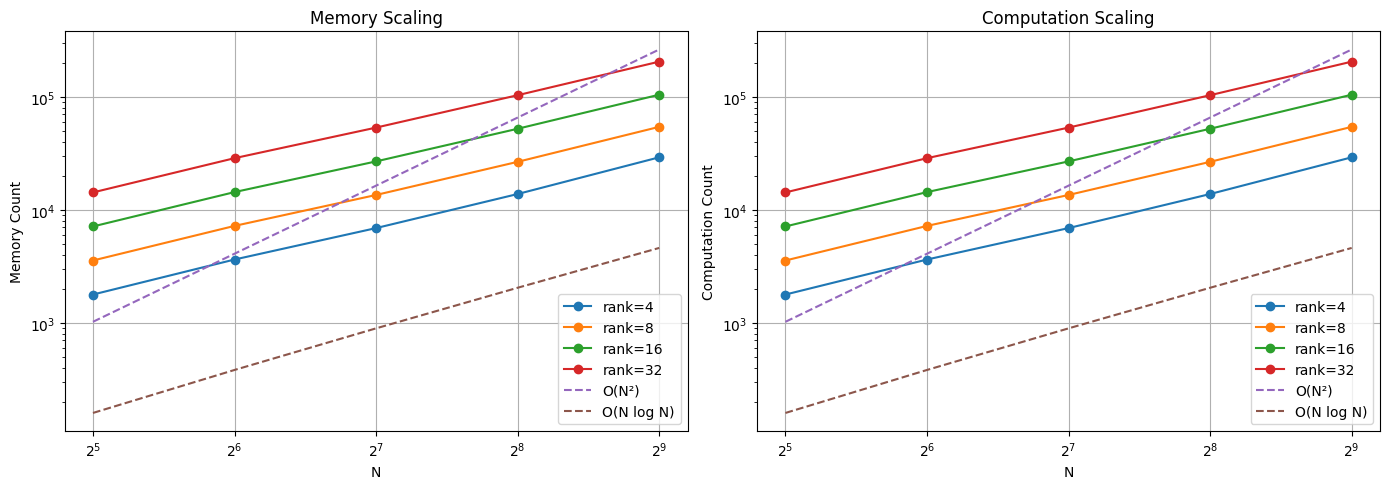

34032


In [ ]:
import matplotlib.pyplot as plt
import math


# Memory model
def count_memory(N, l, rank):
    N = int(N)
    if l == 1:
        return (2 * ((N // 2) ** 2)) + (4 * rank * (N // 2)) + (2 * rank)
    return (2 * count_memory(N // 2, l - 1, rank)) + (4 * rank * (N // 2)) + (2 * rank)


def count_computations(N, l, rank):
    if l == 1:
        return 2 * ((N // 2) ** 2 + (2 * rank * (N // 2)) + rank)
    return 2 * (count_computations(N // 2, l - 1, rank)
                + (2 * rank * (N // 2))
                + rank)

levels = 6
ranks = [4, 8, 16, 32]
Ns = [2**k for k in range(5, 10)]  # 32 → 8192

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Memory plot
all_mem = []
for rank in ranks:
    mem = [count_memory(N, levels, rank) for N in Ns]
    all_mem.append(mem)
    axes[0].plot(Ns, mem, marker='o', label=f"rank={rank}")

# Reference curves
N2 = [N**2 for N in Ns]
NlogN = [N * math.log2(N) for N in Ns]


axes[0].plot(Ns, N2, '--', label="O(N²)")
axes[0].plot(Ns, NlogN, '--', label="O(N log N)")

axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("N")
axes[0].set_ylabel("Memory Count")
axes[0].set_title("Memory Scaling")
axes[0].legend()
axes[0].grid(True)

# Computation plot
all_comp = []
for rank in ranks:
    comp = [count_computations(N, levels, rank) for N in Ns]
    all_comp.append(comp)
    axes[1].plot(Ns, comp, marker='o', label=f"rank={rank}")



max_comp = max(max(c) for c in all_comp)
scale_n3 = max(N2) / max_comp
scale_nlogn = max(NlogN) / max_comp

axes[1].plot(Ns, N2, '--', label="O(N²)")
axes[1].plot(Ns, NlogN, '--', label="O(N log N)")

axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("N")
axes[1].set_ylabel("Computation Count")
axes[1].set_title("Computation Scaling")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(count_memory(384,4,8))

# **Task 4**


1.   Changed the code to build N*M instead of N*N
2.   https://github.com/lucidrains/vit-pytorch/blob/main/vit_pytorch/vit.py --- used this vit implementation
3.   Trained and tested on CIFAR10 detaset(with epochs=50)



Original implementation of vit from the github

In [ ]:
# https://github.com/lucidrains/vit-pytorch/blob/main/vit_pytorch/vit.py

import torch
from torch import nn

from einops import rearrange, repeat
from einops.layers.torch import Rearrange

# helpers

def pair(t):
    return t if isinstance(t, tuple) else (t, t)

# classes

class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn
    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)

class Attention(nn.Module):
    def __init__(self, dim, heads = 8, dim_head = 64, dropout = 0.):
        super().__init__()
        inner_dim = dim_head *  heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.attend = nn.Softmax(dim = -1)
        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale

        attn = self.attend(dots)

        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout = 0.):
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, Attention(dim, heads = heads, dim_head = dim_head, dropout = dropout)),
                PreNorm(dim, FeedForward(dim, mlp_dim, dropout = dropout))
            ]))
    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return x

class ViT(nn.Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads, mlp_dim, pool = 'cls', channels = 3, dim_head = 64, dropout = 0., emb_dropout = 0.):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be divisible by the patch size.'

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        patch_dim = channels * patch_height * patch_width
        assert pool in {'cls', 'mean'}, 'pool type must be either cls (cls token) or mean (mean pooling)'

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1 = patch_height, p2 = patch_width),
            nn.Linear(patch_dim, dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)

        self.pool = pool
        self.to_latent = nn.Identity()

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, img):
        x = self.to_patch_embedding(img)
        b, n, _ = x.shape

        cls_tokens = repeat(self.cls_token, '() n d -> b n d', b = b)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :(n + 1)]
        x = self.dropout(x)

        x = self.transformer(x)

        x = x.mean(dim = 1) if self.pool == 'mean' else x[:, 0]

        x = self.to_latent(x)
        return self.mlp_head(x)

Modified version,replaced dense Linear with HierarchicalLinear

(level = 4, rank = 8)

In [ ]:
import torch
from torch import nn

from einops import rearrange, repeat
from einops.layers.torch import Rearrange


# 1. Hierarchical Low-Rank Matrix Classes
class TrainableUVBlock(nn.Module):
    def __init__(self, in_dim, out_dim, rank):
        super().__init__()
        self.U = nn.Parameter(torch.randn(out_dim, rank) * 0.02)
        self.S = nn.Parameter(torch.ones(rank))
        self.V = nn.Parameter(torch.randn(rank, in_dim) * 0.02)

    def forward(self, x):

        xV = x @ self.V.T
        xVS = xV * self.S
        return xVS @ self.U.T


class RectangularHierarchicalLowRank(nn.Module):
    def __init__(self, in_dim, out_dim, rank=8, level=2, min_dim=16):
        super().__init__()

        if level == 0 or min(in_dim, out_dim) <= min_dim:
            self.is_leaf = True
            self.weight = nn.Parameter(torch.randn(out_dim, in_dim) * 0.02)
            return

        self.is_leaf = False

        in_mid  = in_dim  // 2
        out_mid = out_dim // 2

        self.in_mid  = in_mid
        self.out_mid = out_mid

        self.A11 = RectangularHierarchicalLowRank(in_mid, out_mid, rank, level - 1, min_dim)
        self.A22 = RectangularHierarchicalLowRank(in_dim - in_mid, out_dim - out_mid, rank, level - 1, min_dim)

        self.A12 = TrainableUVBlock(in_dim - in_mid, out_mid, rank)
        self.A21 = TrainableUVBlock(in_mid, out_dim - out_mid, rank)

    def forward(self, x):
        if self.is_leaf:
            return x @ self.weight.T

        x1 = x[:, :self.in_mid]
        x2 = x[:, self.in_mid:]

        y1 = self.A11(x1) + self.A12(x2)
        y2 = self.A21(x1) + self.A22(x2)

        return torch.cat([y1, y2], dim=1)


class HierarchicalLinear(nn.Module):
    def __init__(self, in_dim, out_dim, rank=8, level=2):
        super().__init__()
        self.hmat = RectangularHierarchicalLowRank(
            in_dim=in_dim,
            out_dim=out_dim,
            rank=rank,
            level=level
        )

    def forward(self, x):
        b, n, d = x.shape
        x = x.reshape(b * n, d)
        y = self.hmat(x)
        return y.reshape(b, n, -1)


# 2. Vision Transformer Classes
def pair(t):
    return t if isinstance(t, tuple) else (t, t)

class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn
    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)

class Attention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, dropout=0., rank=8, level=2):
        super().__init__()

        inner_dim = dim_head * heads
        self.heads = heads
        self.scale = dim_head ** -0.5

        self.to_q = HierarchicalLinear(dim, inner_dim, rank, level)
        self.to_k = HierarchicalLinear(dim, inner_dim, rank, level)
        self.to_v = HierarchicalLinear(dim, inner_dim, rank, level)

        self.attend = nn.Softmax(dim=-1)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        q = self.to_q(x)
        k = self.to_k(x)
        v = self.to_v(x)

        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h=self.heads), (q, k, v))

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        attn = self.attend(dots)

        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')

        return self.to_out(out)

class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout=0., rank=8, level=2):
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, Attention(dim, heads=heads, dim_head=dim_head, dropout=dropout, rank=rank, level=level)),
                PreNorm(dim, FeedForward(dim, mlp_dim, dropout=dropout))
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return x

class ViT(nn.Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads, mlp_dim,
                 pool='cls', channels=3, dim_head=64, dropout=0., emb_dropout=0.,
                 rank=8, level=1):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        assert image_height % patch_height == 0 and image_width % patch_width == 0, \
            'Image dimensions must be divisible by the patch size.'

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        patch_dim   = channels * patch_height * patch_width
        assert pool in {'cls', 'mean'}, 'pool type must be either cls or mean'

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_height, p2=patch_width),
            nn.Linear(patch_dim, dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token     = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout       = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout, rank=rank, level=level)

        self.pool       = pool
        self.to_latent  = nn.Identity()

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, img):
        x = self.to_patch_embedding(img)
        b, n, _ = x.shape

        cls_tokens = repeat(self.cls_token, '() n d -> b n d', b=b)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :(n + 1)]
        x = self.dropout(x)

        x = self.transformer(x)

        x = x.mean(dim=1) if self.pool == 'mean' else x[:, 0]

        x = self.to_latent(x)
        return self.mlp_head(x)

Tensorised version

In [ ]:
import torch
from torch import nn
from einops import rearrange, repeat
from einops.layers.torch import Rearrange



class TensorizedUVBlock(nn.Module):
    def __init__(self, in_dim, out_dim, rank):
        super().__init__()
        # 3 = Q, K, V
        self.U = nn.Parameter(torch.randn(3, out_dim, rank) * 0.02)
        self.S = nn.Parameter(torch.ones(3, rank))
        self.V = nn.Parameter(torch.randn(3, rank, in_dim) * 0.02)

    def forward(self, x):
        # x: (3, BN, in_dim)

        xV = torch.matmul(x, self.V.transpose(-1, -2))
        xVS = xV * self.S.unsqueeze(1)
        return torch.matmul(xVS, self.U.transpose(-1, -2))


class TensorizedRectangularHierarchicalLowRank(nn.Module):
    def __init__(self, in_dim, out_dim, rank=8, level=2, min_dim=16):
        super().__init__()

        if level == 0 or min(in_dim, out_dim) <= min_dim:
            self.is_leaf = True
            self.weight = nn.Parameter(torch.randn(3, out_dim, in_dim) * 0.02)
            return

        self.is_leaf = False

        in_mid  = in_dim  // 2
        out_mid = out_dim // 2

        self.in_mid  = in_mid
        self.out_mid = out_mid

        self.A11 = TensorizedRectangularHierarchicalLowRank(
            in_mid, out_mid, rank, level - 1, min_dim
        )
        self.A22 = TensorizedRectangularHierarchicalLowRank(
            in_dim - in_mid, out_dim - out_mid, rank, level - 1, min_dim
        )

        self.A12 = TensorizedUVBlock(in_dim - in_mid, out_mid, rank)
        self.A21 = TensorizedUVBlock(in_mid, out_dim - out_mid, rank)

    def forward(self, x):

        if self.is_leaf:
            return torch.matmul(x, self.weight.transpose(-1, -2))

        x1 = x[..., :self.in_mid]
        x2 = x[..., self.in_mid:]

        y1 = self.A11(x1) + self.A12(x2)
        y2 = self.A21(x1) + self.A22(x2)

        return torch.cat([y1, y2], dim=-1)


class TensorizedHierarchicalLinear(nn.Module):
    def __init__(self, in_dim, out_dim, rank=8, level=2):
        super().__init__()
        self.hmat = TensorizedRectangularHierarchicalLowRank(
            in_dim=in_dim,
            out_dim=out_dim,
            rank=rank,
            level=level
        )

    def forward(self, x):
        b, n, d = x.shape

        x = x.reshape(b * n, d)
        x3 = x.unsqueeze(0).repeat(3, 1, 1)

        y = self.hmat(x3)

        return y.permute(1, 0, 2).reshape(b, n, 3, -1)



def pair(t):
    return t if isinstance(t, tuple) else (t, t)


class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)


class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


class Attention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, dropout=0., rank=8, level=2):
        super().__init__()

        inner_dim = dim_head * heads
        self.heads = heads
        self.scale = dim_head ** -0.5

        # Single tensorized hierarchical projection
        self.to_qkv = TensorizedHierarchicalLinear(dim, inner_dim, rank, level)

        self.attend = nn.Softmax(dim=-1)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):

        qkv = self.to_qkv(x)  # (B, N, 3, inner_dim)
        q, k, v = qkv.unbind(dim=2)

        q, k, v = map(
            lambda t: rearrange(t, 'b n (h d) -> b h n d', h=self.heads),
            (q, k, v)
        )

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        attn = self.attend(dots)

        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')

        return self.to_out(out)


class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout=0., rank=8, level=2):
        super().__init__()

        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, Attention(dim, heads, dim_head, dropout, rank, level)),
                PreNorm(dim, FeedForward(dim, mlp_dim, dropout))
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return x


class ViT(nn.Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads, mlp_dim,
                 pool='cls', channels=3, dim_head=64, dropout=0., emb_dropout=0.,
                 rank=8, level=1):
        super().__init__()

        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        assert image_height % patch_height == 0 and image_width % patch_width == 0

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        patch_dim   = channels * patch_height * patch_width

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)',
                      p1=patch_height, p2=patch_width),
            nn.Linear(patch_dim, dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token     = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout       = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim,
                                       dropout, rank, level)

        self.pool = pool

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, img):

        x = self.to_patch_embedding(img)
        b, n, _ = x.shape

        cls_tokens = repeat(self.cls_token, '() n d -> b n d', b=b)
        x = torch.cat((cls_tokens, x), dim=1)

        x += self.pos_embedding[:, :(n + 1)]
        x = self.dropout(x)

        x = self.transformer(x)

        x = x.mean(dim=1) if self.pool == 'mean' else x[:, 0]

        return self.mlp_head(x)

Train/Test script used

In [ ]:

# Train lucidrains ViT on CIFAR-10


import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


# Device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# CIFAR-10 dataset

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)


# Model (ViT initialisation)
model = ViT(
    image_size=32,
    patch_size=4,
    num_classes=10,
    dim=192,
    depth=6,
    heads=6,
    mlp_dim=512,
    dropout=0.1,
    emb_dropout=0.1
).to(device)

print("Model initialized")


# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=200
)


# Train / test loops
def train_one_epoch():
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(trainloader), 100. * correct / total


@torch.no_grad()
def evaluate():
    model.eval()
    correct = 0
    total = 0

    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return 100. * correct / total


# Training
epochs = 50

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch()
    test_acc = evaluate()
    scheduler.step()

    print(
        f"Epoch [{epoch+1:03d}/{epochs}] | "
        f"Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Acc: {test_acc:.2f}%"
    )


Script to get the count of model parameters

In [ ]:
model = ViT(
    image_size=32,
    patch_size=4,
    num_classes=10,
    dim=192,
    depth=6,
    heads=6,
    mlp_dim=512,
)

# 2. Count parameters immediately
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {count_params(model)}")

Script to observe the difference in accuracy btw the original and the Hmatrix Modified one for both training and testing

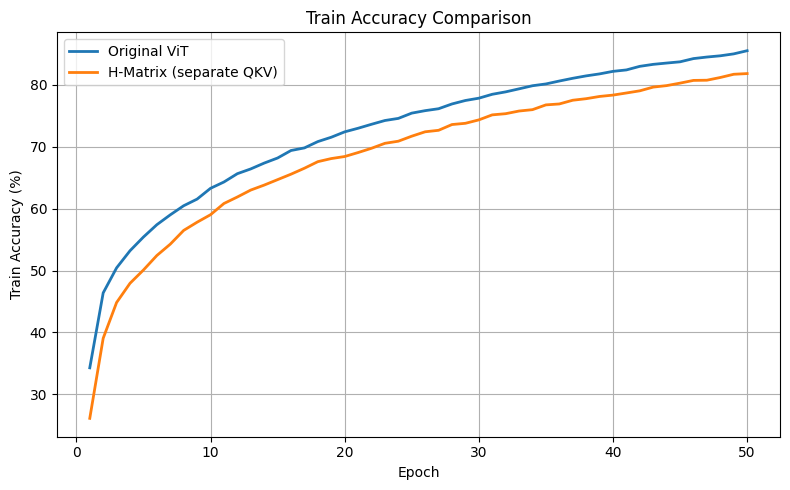

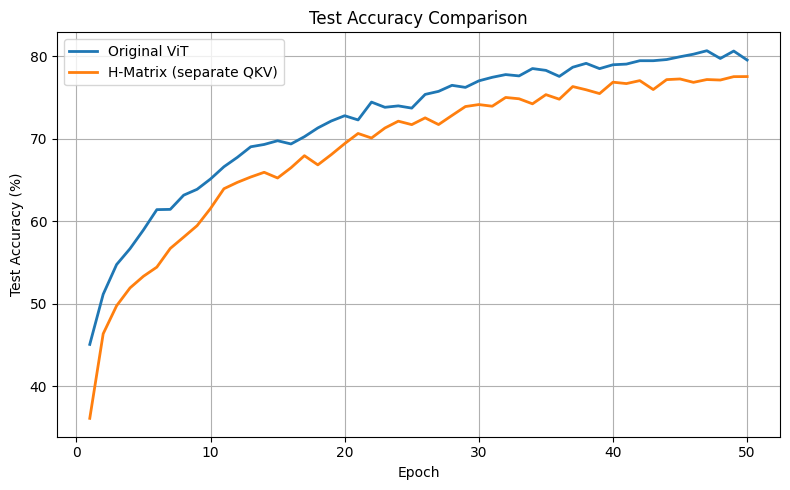

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Epochs
epochs = np.arange(1, 51)

# ================================
# Original Architecture
# ================================

orig_train_acc = [
    34.30, 46.39, 50.43, 53.19, 55.40, 57.39, 58.98, 60.45, 61.52, 63.26,
    64.28, 65.62, 66.39, 67.33, 68.15, 69.36, 69.78, 70.80, 71.50, 72.37,
    72.95, 73.59, 74.20, 74.54, 75.39, 75.79, 76.10, 76.87, 77.43, 77.80,
    78.43, 78.82, 79.31, 79.81, 80.10, 80.57, 81.01, 81.40, 81.72, 82.13,
    82.36, 82.94, 83.26, 83.47, 83.67, 84.19, 84.44, 84.64, 84.95, 85.46
]

orig_test_acc = [
    45.09, 51.16, 54.76, 56.68, 58.95, 61.41, 61.44, 63.16, 63.87, 65.12,
    66.60, 67.74, 69.02, 69.30, 69.75, 69.36, 70.24, 71.30, 72.14, 72.78,
    72.27, 74.43, 73.80, 73.97, 73.70, 75.36, 75.73, 76.46, 76.21, 77.00,
    77.43, 77.76, 77.60, 78.49, 78.27, 77.54, 78.65, 79.12, 78.48, 78.95,
    79.03, 79.44, 79.44, 79.58, 79.92, 80.23, 80.65, 79.71, 80.61, 79.52
]

# ================================
# H-Matrix (Separate Q, K, V)
# ================================

h_train_acc = [
    26.15, 39.07, 44.84, 47.94, 50.08, 52.42, 54.25, 56.47, 57.79, 59.00,
    60.81, 61.86, 62.98, 63.78, 64.66, 65.54, 66.50, 67.56, 68.06, 68.39,
    69.03, 69.72, 70.52, 70.86, 71.67, 72.38, 72.62, 73.55, 73.75, 74.30,
    75.11, 75.30, 75.73, 75.95, 76.72, 76.87, 77.47, 77.72, 78.08, 78.30,
    78.64, 78.99, 79.59, 79.83, 80.23, 80.67, 80.70, 81.14, 81.66, 81.77
]

h_test_acc = [
    36.14, 46.38, 49.77, 51.93, 53.34, 54.45, 56.71, 58.08, 59.47, 61.55,
    63.94, 64.71, 65.36, 65.93, 65.24, 66.48, 67.94, 66.83, 68.07, 69.40,
    70.63, 70.08, 71.29, 72.12, 71.70, 72.52, 71.71, 72.81, 73.89, 74.13,
    73.93, 74.99, 74.83, 74.22, 75.33, 74.78, 76.31, 75.92, 75.46, 76.84,
    76.67, 77.03, 75.95, 77.15, 77.23, 76.82, 77.16, 77.10, 77.51, 77.52
]


# ================================
# Plot 1: Train Accuracy
# ================================

plt.figure(figsize=(8, 5))
plt.plot(epochs, orig_train_acc, label="Original ViT", linewidth=2)
plt.plot(epochs, h_train_acc, label="H-Matrix (separate QKV)", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Train Accuracy (%)")
plt.title("Train Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ================================
# Plot 2: Test Accuracy
# ================================

plt.figure(figsize=(8, 5))
plt.plot(epochs, orig_test_acc, label="Original ViT", linewidth=2)
plt.plot(epochs, h_test_acc, label="H-Matrix (separate QKV)", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Summary**

**Original implementation:**

Total Parameters: 2983498

Train acc: 85.46

Test acc: 79.52


**HMatrix modified implementation:**

Total Parameters: 2071114 (30.5% decrease)

Train acc: 81.77

Test acc: 77.52


# **For rank  = 8, level = 4**

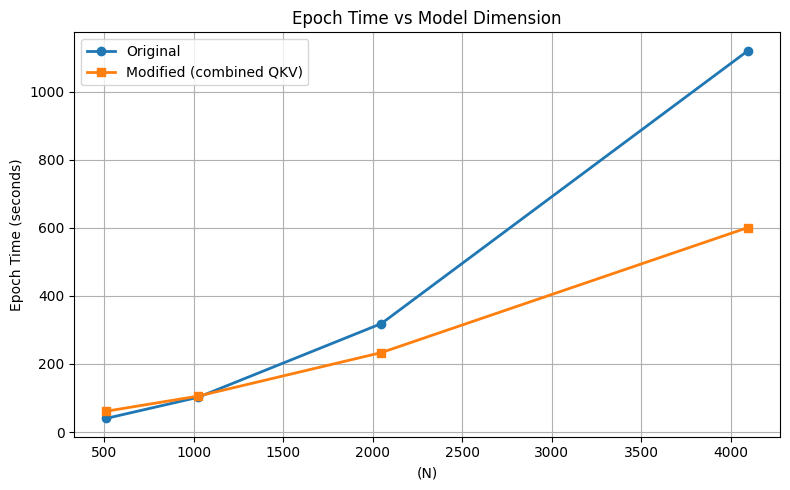

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# N values
N_values = np.array([512, 1024, 2048, 4096])

# Epoch times (in seconds)

# Original
orig_times = np.array([
    40.39,   # N = 512
    102.21,  # N = 1024
    318.68,  # N = 2048
    1119.96  # N = 4096
])

# Modified (combined qkv / to_qkv)
mod_times = np.array([
    61.44,   # N = 512
    105.67,  # N = 1024
    233.47,  # N = 2048
    600.66   # N = 4096
])

# Plot
plt.figure(figsize=(8, 5))

plt.plot(N_values, orig_times, marker='o', linewidth=2, label="Original")
plt.plot(N_values, mod_times, marker='s', linewidth=2, label="Modified (combined QKV)")

plt.xlabel("(N)")
plt.ylabel("Epoch Time (seconds)")
plt.title("Epoch Time vs Model Dimension")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**model = ViT(
    image_size=32,
    patch_size=4,
    num_classes=10,
    dim=1024,
    depth=6,
    heads=8,
    dim_head=128,
    mlp_dim=512,
    dropout=0.1,
    emb_dropout=0.1
).to(device)**

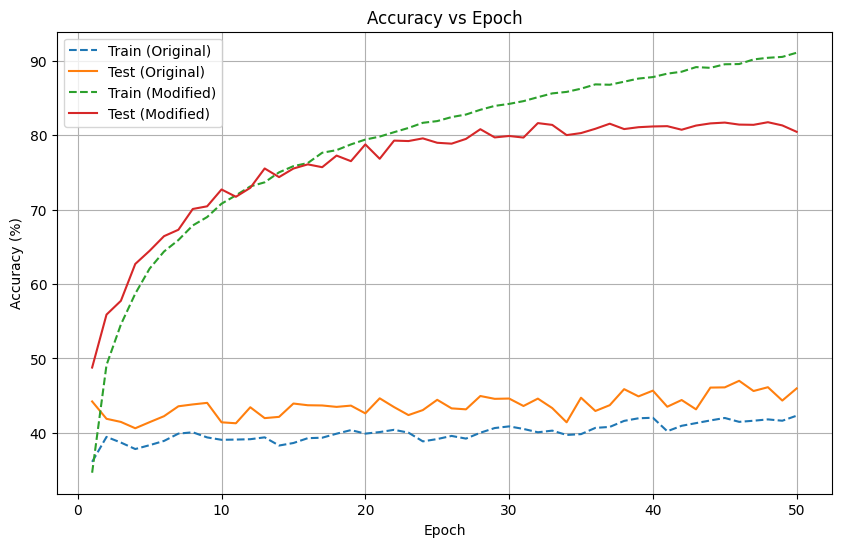

In [ ]:
import matplotlib.pyplot as plt

# ===== Original Model =====
train_acc_original = [
36.12,39.47,38.71,37.84,38.36,38.93,39.91,40.09,39.40,39.08,
39.11,39.16,39.41,38.31,38.65,39.30,39.36,39.90,40.38,39.91,
40.12,40.42,40.04,38.87,39.18,39.60,39.24,40.03,40.66,40.88,
40.54,40.09,40.31,39.73,39.84,40.68,40.81,41.62,41.97,42.04,
40.23,40.96,41.32,41.68,42.01,41.49,41.64,41.82,41.64,42.32
]

test_acc_original = [
44.23,41.90,41.48,40.63,41.45,42.25,43.58,43.83,44.04,41.43,
41.30,43.45,41.99,42.16,43.95,43.72,43.69,43.50,43.67,42.63,
44.65,43.47,42.40,43.07,44.45,43.30,43.17,44.96,44.58,44.62,
43.62,44.61,43.34,41.43,44.73,42.95,43.73,45.88,44.91,45.68,
43.52,44.42,43.17,46.09,46.12,47.00,45.63,46.14,44.35,45.98
]

# ===== Modified Model =====
train_acc_modified = [
34.66,49.12,54.56,58.70,62.07,64.36,65.90,67.86,68.99,70.78,
71.90,73.10,73.65,74.99,75.82,76.24,77.62,77.97,78.74,79.39,
79.79,80.38,80.95,81.64,81.87,82.41,82.75,83.39,83.91,84.18,
84.55,85.08,85.59,85.79,86.22,86.80,86.75,87.16,87.58,87.78,
88.24,88.50,89.12,89.02,89.50,89.53,90.15,90.37,90.49,91.05
]

test_acc_modified = [
48.78,55.89,57.74,62.69,64.46,66.42,67.28,70.07,70.43,72.69,
71.71,72.91,75.51,74.35,75.50,76.06,75.68,77.24,76.49,78.74,
76.81,79.25,79.19,79.55,78.96,78.84,79.48,80.78,79.68,79.87,
79.66,81.60,81.36,79.99,80.26,80.84,81.52,80.80,81.05,81.15,
81.19,80.71,81.27,81.56,81.67,81.40,81.37,81.72,81.29,80.43
]

# ===== Plot =====
epochs = range(1, 51)

plt.figure(figsize=(10,6))

plt.plot(epochs, train_acc_original, label="Train (Original)", linestyle="--")
plt.plot(epochs, test_acc_original, label="Test (Original)")

plt.plot(epochs, train_acc_modified, label="Train (Modified)", linestyle="--")
plt.plot(epochs, test_acc_modified, label="Test (Modified)")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)

plt.show()


# **Task**

**model = ViT(
    image_size=32,
    patch_size=4,
    num_classes=10,
    dim=4096,
    depth=6,
    heads=16,
    mlp_dim=512,
    dim_head=256,
    dropout=0.1,
    emb_dropout=0.1,
    rank=128,
    level=4
).to(device)**

**48%** decrease in no of param

Original took **1000s** more than modified for training(5 epochs)

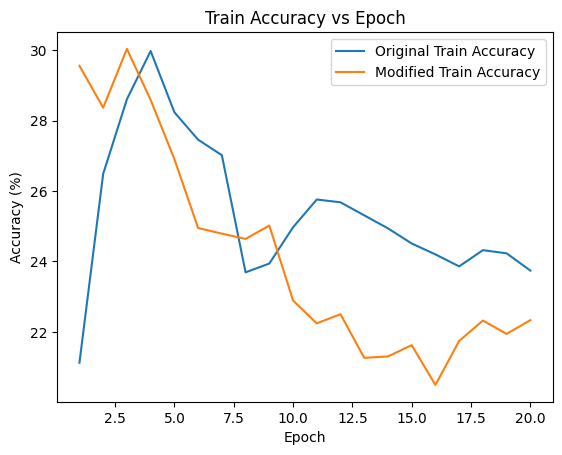

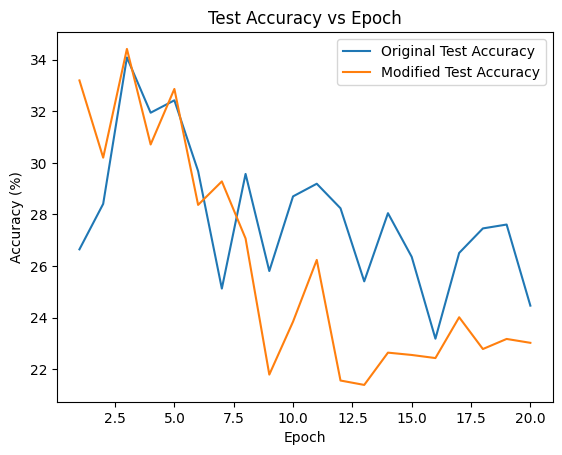

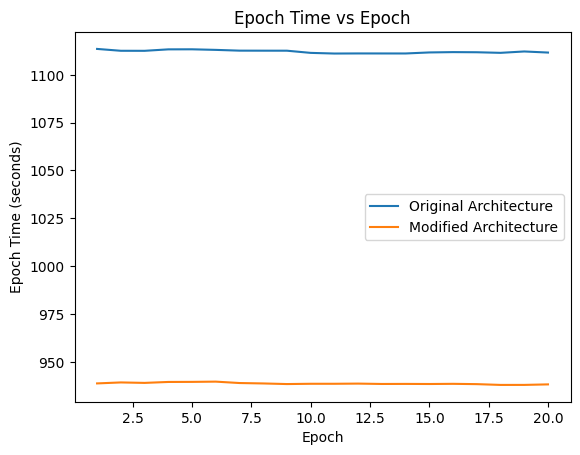

In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 21))

# -------------------------
# Original Architecture
# -------------------------
orig_train_acc = [
    21.12, 26.49, 28.61, 29.98, 28.24,
    27.46, 27.02, 23.69, 23.94, 24.97,
    25.76, 25.68, 25.31, 24.94, 24.51,
    24.20, 23.86, 24.32, 24.23, 23.74
]

orig_test_acc = [
    26.65, 28.41, 34.08, 31.94, 32.42,
    29.68, 25.13, 29.57, 25.81, 28.70,
    29.19, 28.24, 25.41, 28.05, 26.36,
    23.19, 26.51, 27.46, 27.61, 24.47
]

orig_time = [
    1113.54, 1112.57, 1112.55, 1113.31, 1113.34,
    1113.04, 1112.64, 1112.62, 1112.61, 1111.47,
    1111.13, 1111.18, 1111.17, 1111.16, 1111.70,
    1111.87, 1111.80, 1111.49, 1112.21, 1111.64
]

# -------------------------
# Modified Architecture
# -------------------------
mod_train_acc = [
    29.56, 28.37, 30.04, 28.59, 26.91,
    24.95, 24.79, 24.64, 25.02, 22.89,
    22.24, 22.50, 21.26, 21.30, 21.62,
    20.49, 21.74, 22.32, 21.94, 22.33
]

mod_test_acc = [
    33.19, 30.20, 34.41, 30.71, 32.86,
    28.37, 29.28, 27.07, 21.80, 23.85,
    26.24, 21.57, 21.40, 22.65, 22.56,
    22.44, 24.02, 22.79, 23.18, 23.03
]

mod_time = [
    938.71, 939.22, 938.98, 939.47, 939.51,
    939.64, 938.91, 938.69, 938.37, 938.52,
    938.52, 938.61, 938.42, 938.45, 938.40,
    938.49, 938.33, 937.92, 937.93, 938.20
]

# ==========================================================
# Plot 1: Train Accuracy Comparison
# ==========================================================
plt.figure()
plt.plot(epochs, orig_train_acc, label="Original Train Accuracy")
plt.plot(epochs, mod_train_acc, label="Modified Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train Accuracy vs Epoch")
plt.legend()
plt.show()

# ==========================================================
# Plot 2: Test Accuracy Comparison
# ==========================================================
plt.figure()
plt.plot(epochs, orig_test_acc, label="Original Test Accuracy")
plt.plot(epochs, mod_test_acc, label="Modified Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy vs Epoch")
plt.legend()
plt.show()

# ==========================================================
# Plot 3: Time Comparison
# ==========================================================
plt.figure()
plt.plot(epochs, orig_time, label="Original Architecture")
plt.plot(epochs, mod_time, label="Modified Architecture")
plt.xlabel("Epoch")
plt.ylabel("Epoch Time (seconds)")
plt.title("Epoch Time vs Epoch")
plt.legend()
plt.show()
